# 06_comparison — Role A: Comparison of Results

Tổng hợp `outputs/results.csv` (5 dòng: M0 baseline, M1 pruning, M2a/M2b class imbalance,
M3 early-warning) sau khi B/C/D/E đã train xong toàn bộ. Dùng cho mục **g. Comparison of
Results** trong báo cáo.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path | None = None) -> Path:
    """Find the nearest ancestor containing the shared data pipeline."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "data.py").is_file():
            return candidate
    raise FileNotFoundError("Không tìm thấy repo root chứa src/data.py")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIG_DIR = REPO_ROOT / "figures"
RESULTS_PATH = REPO_ROOT / "outputs" / "results.csv"

df = pd.read_csv(RESULTS_PATH)
assert df["model_id"].is_unique, "results.csv co model_id trung lap!"
assert set(df["model_id"]) == {"M0", "M1", "M2a", "M2b", "M3"}, "Thieu hoac du model so voi ke hoach"
df = df.set_index("model_id").loc[["M0", "M1", "M2a", "M2b", "M3"]].reset_index()
df[["test_acc", "error_rate", "precision_macro", "recall_macro", "f1_macro",
    "roc_auc_macro", "recall_dropout", "recall_enrolled", "recall_graduate"]].round(4)

,test_acc,error_rate,precision_macro,recall_macro,f1_macro,roc_auc_macro,recall_dropout,recall_enrolled,recall_graduate
0,0.6689,0.3311,0.6076,0.6093,0.6083,0.7195,0.6796,0.3836,0.7647
1,0.7559,0.2441,0.7105,0.6602,0.6729,0.8477,0.6866,0.3459,0.9480
2,0.6508,0.3492,0.5843,0.5878,0.5854,0.7053,0.6796,0.3396,0.7443
3,0.6881,0.3119,0.6365,0.6429,0.6387,0.7421,0.7077,0.4654,0.7557
4,0.5412,0.4588,0.4921,0.4944,0.4931,0.6254,0.5317,0.3270,0.6244


## Bảng so sánh đầy đủ

Nhãn model đọc theo `docs/02-DATASET-VA-CONG-VIEC.md`:
- **M0** — Baseline (`DecisionTreeClassifier(random_state=42)`, không giới hạn) — role B
- **M1** — Cost-complexity pruning (`ccp_alpha` chọn qua CV trên train + grid depth/leaf) — role C
- **M2a** — `class_weight='balanced'` — role D
- **M2b** — SMOTE chỉ trên train — role D
- **M3** — Loại 12 cột kết quả học kỳ, dự báo sớm — role E

In [2]:
display_cols = ["model_id", "model_name", "train_acc", "test_acc", "error_rate",
                 "precision_macro", "recall_macro", "f1_macro", "roc_auc_macro",
                 "recall_dropout", "recall_enrolled", "recall_graduate",
                 "tree_depth", "n_leaves", "author"]
comparison_table = df[display_cols].copy()
comparison_table.to_csv(REPO_ROOT / "outputs" / "comparison_table.csv", index=False)
comparison_table

,model_id,model_name,train_acc,test_acc,error_rate,precision_macro,recall_macro,f1_macro,roc_auc_macro,recall_dropout,recall_enrolled,recall_graduate,tree_depth,n_leaves,author
0,M0,Baseline Decision Tree (Gini),1.000000,0.668927,0.331073,0.607642,0.609310,0.608271,0.719456,0.679577,0.383648,0.764706,27,634,B
1,M1,Cost-complexity pruned tree,0.768014,0.755932,0.244068,0.710494,0.660165,0.672925,0.847692,0.686620,0.345912,0.947964,5,17,C
2,M2a,Decision Tree with Balanced Class Weights,1.000000,0.650847,0.349153,0.584250,0.587848,0.585409,0.705321,0.679577,0.339623,0.744344,28,696,D
3,M2b,Decision Tree with SMOTE on Training Set,1.000000,0.688136,0.311864,0.636513,0.642937,0.638747,0.742122,0.707746,0.465409,0.755656,39,847,D
4,M3,Early-warning Decision Tree (no semester outco...,1.000000,0.541243,0.458757,0.492090,0.494390,0.493050,0.625355,0.531690,0.327044,0.624434,30,963,E


## Hình so sánh tổng hợp — `figures/comparison.png`

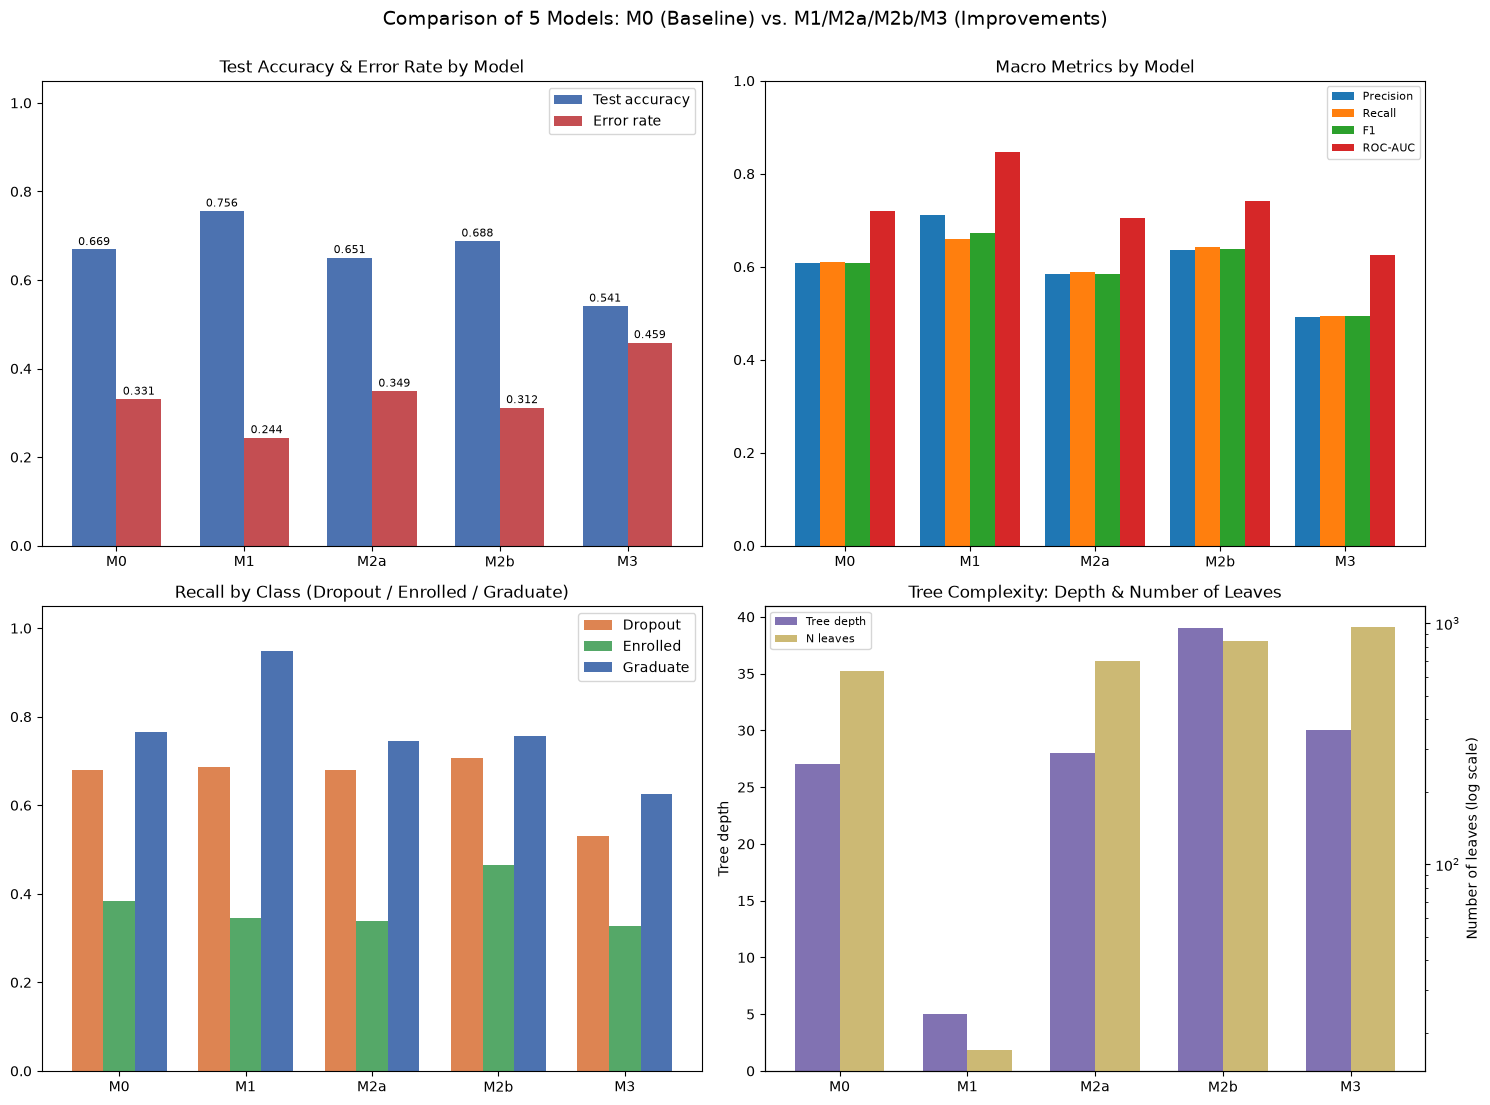

In [3]:
models = df["model_id"].tolist()
model_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]  # M0,M1,M2a,M2b,M3
class_colors = {"Dropout": "#DD8452", "Enrolled": "#55A868", "Graduate": "#4C72B0"}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Panel 1: test accuracy vs error rate ---
ax = axes[0, 0]
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, df["test_acc"], width, label="Test accuracy", color="#4C72B0")
ax.bar(x + width/2, df["error_rate"], width, label="Error rate", color="#C44E52")
for i, (acc, err) in enumerate(zip(df["test_acc"], df["error_rate"])):
    ax.text(i - width/2, acc + 0.01, f"{acc:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, err + 0.01, f"{err:.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.set_title("Test Accuracy & Error Rate by Model")
ax.legend()

# --- Panel 2: macro metrics ---
ax = axes[0, 1]
macro_cols = ["precision_macro", "recall_macro", "f1_macro", "roc_auc_macro"]
macro_labels = ["Precision", "Recall", "F1", "ROC-AUC"]
width2 = 0.2
for j, (col, label) in enumerate(zip(macro_cols, macro_labels)):
    ax.bar(x + (j - 1.5) * width2, df[col], width2, label=label)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.set_title("Macro Metrics by Model")
ax.legend(fontsize=8)

# --- Panel 3: per-class recall ---
ax = axes[1, 0]
recall_cols = ["recall_dropout", "recall_enrolled", "recall_graduate"]
recall_labels = ["Dropout", "Enrolled", "Graduate"]
width3 = 0.25
for j, (col, label) in enumerate(zip(recall_cols, recall_labels)):
    ax.bar(x + (j - 1) * width3, df[col], width3, label=label, color=class_colors[label])
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.set_title("Recall by Class (Dropout / Enrolled / Graduate)")
ax.legend()

# --- Panel 4: tree complexity (depth & leaves, leaves on log scale) ---
ax = axes[1, 1]
ax2 = ax.twinx()
ax.bar(x - width/2, df["tree_depth"], width, label="Tree depth", color="#8172B2")
ax2.bar(x + width/2, df["n_leaves"], width, label="N leaves", color="#CCB974")
ax2.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Tree depth")
ax2.set_ylabel("Number of leaves (log scale)")
ax.set_title("Tree Complexity: Depth & Number of Leaves")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

fig.suptitle("Comparison of 5 Models: M0 (Baseline) vs. M1/M2a/M2b/M3 (Improvements)", fontsize=14, y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Model tốt nhất theo từng tiêu chí

Không có một model "tốt nhất tuyệt đối" — mỗi model trả lời một câu hỏi khác nhau. Bảng dưới
liệt kê model dẫn đầu theo từng chỉ số để dùng cho mục g.

In [4]:
metrics_to_rank = ["test_acc", "f1_macro", "roc_auc_macro", "recall_dropout",
                    "recall_enrolled", "recall_graduate"]
best_per_metric = {}
for m in metrics_to_rank:
    best_row = df.loc[df[m].idxmax()]
    best_per_metric[m] = (best_row["model_id"], round(best_row[m], 4))

best_leaves = df.loc[df["n_leaves"].idxmin()]
best_per_metric["n_leaves (fewest = most interpretable)"] = (best_leaves["model_id"], int(best_leaves["n_leaves"]))

pd.DataFrame(best_per_metric, index=["best_model", "value"]).T

,best_model,value
test_acc,M1,0.7559
f1_macro,M1,0.6729
roc_auc_macro,M1,0.8477
recall_dropout,M2b,0.7077
recall_enrolled,M2b,0.4654
recall_graduate,M1,0.948
n_leaves (fewest = most interpretable),M1,17


## Kiểm tra pipeline dùng chung

Xác nhận cả 5 model đều dùng đúng `random_state=42` và cùng split từ `get_train_test()`
(gián tiếp qua việc mọi model đều đánh giá trên `X_test` có 885 dòng — số held-out test cố
định của cả nhóm).

In [5]:
import json

for _, row in df.iterrows():
    params = json.loads(row["params"])
    rs = params.get("random_state", params.get("smote_random_state"))
    print(f"{row['model_id']:>4} | author={row['author']} | random_state={rs} | "
          f"depth={row['tree_depth']:>3} | leaves={row['n_leaves']:>4}")

  M0 | author=B | random_state=42 | depth= 27 | leaves= 634
  M1 | author=C | random_state=42 | depth=  5 | leaves=  17
 M2a | author=D | random_state=42 | depth= 28 | leaves= 696
 M2b | author=D | random_state=42 | depth= 39 | leaves= 847
  M3 | author=E | random_state=42 | depth= 30 | leaves= 963
